## Definição e carregamento de bases de dados para Matching

Para a estimação do modelo, serão utilizadas as seguintes covariáveis:
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação Setorial no PIB (IBGE)
 * Educação média (RAIS)
 * Receita Corrente Municipal Bruta (IPEADATA)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import warnings
import requests
import io

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm

from synthdid.model import SynthDID

warnings.simplefilter(action="ignore", category=FutureWarning)


In [2]:
# ================================================================
# MONKEY-PATCH: corrige SynthDID.plot para pandas >= 2.0
# (Index @ array retorna escalar; convertemos o index para np.array)
# ================================================================
from synthdid import plot as _sdid_plot

def _plot_fixed(self, model="sdid", figsize=(10, 7)):
    _idx = lambda ix: np.asarray(ix, dtype=np.float64)
    result = pd.DataFrame({"actual_y": self.target_y()})
    post_actural_treat = result.loc[self.post_term[0]:, "actual_y"].mean()
    post_point = float(np.mean(_idx(self.Y_post_c.index)))

    if model == "sdid":
        result["sdid"] = self.sdid_trajectory()
        time_result = pd.DataFrame({"time": self.Y_pre_c.index,
                                    "sdid_weight": np.round(self.hat_lambda, 3)})
        pre_point = float(np.dot(_idx(self.Y_pre_c.index), self.hat_lambda))
        pre_sdid  = float(result["sdid"].head(len(self.hat_lambda)).values @ self.hat_lambda)
        post_sdid = result.loc[self.post_term[0]:, "sdid"].mean()
        pre_treat = float((self.Y_pre_t.T @ self.hat_lambda).values[0])
        cf_post   = pre_treat + (post_sdid - pre_sdid)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["sdid"].plot(ax=ax, color="red", lw=1, label="sintetico", alpha=0.6)
        for yp, c in [([pre_sdid, post_sdid], "red"),
                      ([pre_treat, post_actural_treat], "blue"),
                      ([pre_treat, cf_post], "blue")]:
            ls = "--" if yp[1] == cf_post else "-"
            ax.plot([pre_point, post_point], yp, marker="o", color=c, lw=1, ls=ls,
                    alpha=0.3 if ls == "--" else 1.0)
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax2 = ax.twinx(); ax2.bar(time_result["time"], time_result["sdid_weight"],
                                  color="#ff7f00", width=1.0, alpha=0.6); ax2.set_ylim(0,3); ax2.axis("off")
        ax.set_title(f"SDID : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()
    elif model == "sc":
        result["sc"] = self.sc_potentical_outcome()
        post_sc = result.loc[self.post_term[0]:, "sc"].mean()
        pre_treat = float(self.Y_pre_t.mean()); cf_post = float(post_sc)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["sc"].plot(ax=ax, color="red", lw=1, label="sintetico", alpha=0.6)
        ax.annotate("", xy=(post_point, post_actural_treat), xytext=(post_point, cf_post),
                    arrowprops=dict(arrowstyle="-|>", color="black"))
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax.set_title(f"SC : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()
    elif model == "did":
        result["did"] = self.df[self.control].mean(axis=1)
        pre_point = float(np.mean(_idx(self.Y_pre_c.index)))
        pre_did = result.loc[:self.pre_term[1], "did"].mean()
        post_did = result.loc[self.post_term[0]:, "did"].mean()
        pre_treat = float(pd.DataFrame(self.Y_pre_t).mean(axis=1).mean())
        cf_post = pre_treat + (post_did - pre_did)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["did"].plot(ax=ax, color="red", lw=1, label="media controles", alpha=0.6)
        for yp, c in [([pre_did, post_did], "red"),
                      ([pre_treat, post_actural_treat], "blue"),
                      ([pre_treat, cf_post], "blue")]:
            ls = "--" if yp[1] == cf_post else "-"
            ax.plot([pre_point, post_point], yp, marker="o", color=c, lw=1, ls=ls,
                    alpha=0.3 if ls == "--" else 1.0)
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax.set_title(f"DID : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()

SynthDID.plot = _plot_fixed
print("Monkey-patch aplicado")


Monkey-patch aplicado


## Carregamento de dados do IBGE via GitHub
* PIB per Capita
* População
* Participação dos setores econômicos

> **Fonte:** `pib_percapita_municipios.parquet` (GitHub Release — mvtp23/TCC).  
> As três bases originais (pib_per_capita, populacao, pib_setor) foram consolidadas
> neste único arquivo e carregadas a seguir.


In [3]:
URL_PIB = (
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_ibge/pib_percapita_municipios.parquet"
)


In [4]:
# Baixar e ler o arquivo parquet diretamente do GitHub
# (o requests lida com o redirect do GitHub Releases)
_resp = requests.get(URL_PIB, headers={"User-Agent": "Mozilla/5.0"}, allow_redirects=True)
_resp.raise_for_status()
df_raw = pd.read_parquet(io.BytesIO(_resp.content))

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape: (77980, 15)

Colunas: ['cod_municipio', 'nome_municipio', 'sigla_uf', 'ano', 'pib_reais', 'populacao', 'pib_percapita_rs', 'vab_agro_reais', 'vab_ind_reais', 'vab_serv_reais', 'vab_adm_reais', 'part_agropecuaria', 'part_industria', 'part_servicos', 'part_adm_publica']


,cod_municipio,nome_municipio,sigla_uf,ano,pib_reais,populacao,pib_percapita_rs,vab_agro_reais,vab_ind_reais,vab_serv_reais,vab_adm_reais,part_agropecuaria,part_industria,part_servicos,part_adm_publica
0,1100015,Alta Floresta D'Oeste - RO,RO,2010,262077000.0,NaN,NaN,69260000.0,16119000.0,62496000.0,93245000.0,28.72,6.68,25.92,38.67
1,1100015,Alta Floresta D'Oeste - RO,RO,2011,280510000.0,24228.0,11577.926366,73328000.0,17942000.0,65486000.0,102539000.0,28.28,6.92,25.26,39.55
2,1100015,Alta Floresta D'Oeste - RO,RO,2012,329029000.0,24069.0,13670.239727,106125000.0,18906000.0,71330000.0,112789000.0,34.33,6.12,23.07,36.48


### Mapeamento de colunas

Ajuste o dicionário `MAPA_COLUNAS` caso os nomes das colunas no parquet
sejam diferentes dos nomes utilizados no restante do notebook.

| Chave (nome no .parquet) | Valor (nome interno do notebook) |
|---|---|
| `cod_municipio` | `cod_municipio` |
| `ano` | `ano` |
| `nome_municipio` | `nome_municipio` |
| `sigla_uf` | `sigla_uf` |
| `pib_per_capita` | `pib_per_capita` |
| `populacao` | `populacao` |
| `pib_total` | `pib_total` |
| `part_servicos` | `part_servicos` |
| `part_industria` | `part_industria` |
| `part_agropecuaria` | `part_agropecuaria` |
| `part_adm_publica` | `part_adm_publica` |


In [5]:
# Renomeie as chaves para os nomes reais do seu arquivo, se necessário
MAPA_COLUNAS = {
    "cod_municipio"    : "cod_municipio",
    "ano"              : "ano",
    "nome_municipio"   : "nome_municipio",
    "sigla_uf"         : "sigla_uf",
    "pib_per_capita"   : "pib_percapita_rs",
    "populacao"        : "populacao",
    "pib_total"        : "pib_REAIS",
    "part_servicos"    : "part_servicos",
    "part_industria"   : "part_industria",
    "part_agropecuaria": "part_agropecuaria",
    "part_adm_publica" : "part_adm_publica",
}

# Rename columns (usando MAPA_COLUNAS) e normalizar nomes esperados pelo notebook
df_pib = df_raw.rename(columns=MAPA_COLUNAS).copy()

# Normalizar possíveis variações de nomes para os nomes internos esperados
_normalize = {
    "pib_REAIS": "pib_total",
    "pib_reais": "pib_total",
    "pib_total": "pib_total",
    "pib_percapita_rs": "pib_per_capita",
    "pib_per_capita": "pib_per_capita",
}

df_pib = df_pib.rename(columns={k: v for k, v in _normalize.items() if k in df_pib.columns})

# Colunas finais desejadas (conformes ao restante do notebook)
colunas_desejadas = [
    "cod_municipio", "ano", "nome_municipio", "sigla_uf",
    "pib_per_capita", "populacao", "pib_total",
    "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
]

# Selecionar apenas colunas presentes e avisar sobre as faltantes
presentes = [c for c in colunas_desejadas if c in df_pib.columns]
faltantes = [c for c in colunas_desejadas if c not in df_pib.columns]
if faltantes:
    print("⚠️ Colunas faltantes após rename:", faltantes)

df_pib = df_pib[presentes].copy()

# Garantir tipos corretos nas chaves de join (padrão do notebook)
df_pib["cod_municipio"] = pd.to_numeric(df_pib["cod_municipio"], errors="coerce")
df_pib["ano"]           = pd.to_numeric(df_pib["ano"],           errors="coerce")
df_pib = df_pib.dropna(subset=["cod_municipio", "ano"])
df_pib["cod_municipio"] = df_pib["cod_municipio"].astype(int)
df_pib["ano"]           = df_pib["ano"].astype(int)

print(f"Shape após seleção: {df_pib.shape}")
df_pib.head(3)

Shape após seleção: (77980, 11)


,cod_municipio,ano,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_total,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,1100015,2010,Alta Floresta D'Oeste - RO,RO,NaN,NaN,262077000.0,25.92,6.68,28.72,38.67
1,1100015,2011,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,280510000.0,25.26,6.92,28.28,39.55
2,1100015,2012,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,329029000.0,23.07,6.12,34.33,36.48


In [6]:
# --- Verificação 1: número de dígitos do código de município ---
n_digitos = df_pib["cod_municipio"].astype(str).str.len().value_counts()
print("Dígitos em cod_municipio:")
print(n_digitos)
if n_digitos.index[0] != 7:
    print("\n⚠️  ATENÇÃO: o notebook usa 7 dígitos; verifique o código de município")
else:
    print("\n✅ Formato compatível com o notebook (7 dígitos)")

# --- Verificação 2: cobertura temporal ---
anos = sorted(df_pib["ano"].unique())
print(f"\nPeríodo disponível: {anos[0]} a {anos[-1]}")
faltando = [a for a in range(2010, 2022) if a not in anos]
if faltando:
    print(f"⚠️  Anos do período de análise faltando: {faltando}")
else:
    print("✅ Cobertura temporal suficiente para o período de análise (2010-2021)")

# --- Verificação 3: duplicatas por chave ---
n_dup = df_pib.duplicated(subset=["cod_municipio", "ano"]).sum()
print(f"\n{'✅' if n_dup == 0 else '⚠️ '} Duplicatas (cod_municipio, ano): {n_dup}")

Dígitos em cod_municipio:
cod_municipio
7    77980
Name: count, dtype: int64

✅ Formato compatível com o notebook (7 dígitos)

Período disponível: 2010 a 2023
✅ Cobertura temporal suficiente para o período de análise (2010-2021)

✅ Duplicatas (cod_municipio, ano): 0


In [7]:
# Detectar se as participações estão em % (0-100) ou proporção (0-1)
cols_part = ["part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"]
if df_pib[cols_part].max().max() > 1:
    df_pib[cols_part] = df_pib[cols_part] / 100
    print("Participações convertidas de % para proporção")
else:
    print("Participações já em proporção — sem conversão")

# pib_servicos = pib_total × part_servicos
df_pib["pib_servicos"] = df_pib["pib_total"] * df_pib["part_servicos"]

# pib_servicos_per_capita = pib_servicos / populacao
df_pib["pib_servicos_per_capita"] = df_pib["pib_servicos"] / df_pib["populacao"]

Participações convertidas de % para proporção


In [8]:
df_ibge = (
    df_pib[[
        "ano", "cod_municipio", "nome_municipio", "sigla_uf",
        "pib_per_capita", "populacao", "pib_servicos", "pib_servicos_per_capita",
        "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
    ]]
    .copy()
    .sort_values(["cod_municipio", "ano"])
    .reset_index(drop=True)
)

print(f"df_ibge: {df_ibge.shape[0]:,} linhas, {df_ibge['cod_municipio'].nunique():,} municípios")
df_ibge

df_ibge: 77,980 linhas, 5,570 municípios


,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_servicos,pib_servicos_per_capita,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,NaN,NaN,6.793036e+07,NaN,0.2592,0.0668,0.2872,0.3867
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,7.085683e+07,2924.584200,0.2526,0.0692,0.2828,0.3955
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,7.590699e+07,3153.724305,0.2307,0.0612,0.3433,0.3648
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,13266.674440,25728.0,7.679812e+07,2985.001749,0.2250,0.0627,0.3416,0.3708
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,14727.857477,25652.0,9.233408e+07,3599.488367,0.2444,0.0614,0.3419,0.3523
...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,90742.750230,3015268.0,1.410752e+11,46786.962019,0.5156,0.0389,0.0041,0.4414
77976,2020,5300108,Brasília - DF,DF,87016.159932,3055149.0,1.288828e+11,42185.434335,0.4848,0.0455,0.0068,0.4629
77977,2021,5300108,Brasília - DF,DF,92732.270204,3094325.0,1.425537e+11,46069.391838,0.4968,0.0398,0.0089,0.4545
77978,2022,5300108,Brasília - DF,DF,116700.426034,2817381.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Logs
df_ibge['log_pib_per_capita']          = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao']               = np.log(df_ibge['populacao'])
df_ibge['log_pib_servicos']            = np.log(df_ibge['pib_servicos'])
df_ibge['log_pib_servicos_per_capita'] = np.log(df_ibge['pib_servicos_per_capita'])

df_ibge = df_ibge.drop(columns=[
    'pib_per_capita', 'populacao', 'pib_servicos', 'pib_servicos_per_capita'
])

# Crescimento anual por município
# diff() dentro do grupo evita herdar o último valor do município anterior
df_ibge = df_ibge.sort_values(['cod_municipio', 'ano'])

df_ibge['%_pib_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge['%_pib_servicos_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_servicos_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge

c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,0.2592,0.0668,0.2872,0.3867,NaN,NaN,18.033994,NaN,NaN,NaN
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,0.2526,0.0692,0.2828,0.3955,9.356856,10.095264,18.076172,7.980908,NaN,NaN
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,0.2307,0.0612,0.3433,0.3648,9.522976,10.088680,18.145019,8.056339,0.180716,0.078350
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,0.2250,0.0627,0.3416,0.3708,9.493010,10.155335,18.156691,8.001356,-0.029521,-0.053499
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,0.2444,0.0614,0.3419,0.3523,9.597496,10.152377,18.340924,8.188547,0.110139,0.205858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,0.5156,0.0389,0.0041,0.4414,11.415784,14.919199,25.672559,10.753360,0.059319,0.085639
77976,2020,5300108,Brasília - DF,DF,0.4848,0.0455,0.0068,0.4629,11.373849,14.932339,25.582169,10.649830,-0.041068,-0.098351
77977,2021,5300108,Brasília - DF,DF,0.4968,0.0398,0.0089,0.4545,11.437472,14.945080,25.682984,10.737904,0.065690,0.092069
77978,2022,5300108,Brasília - DF,DF,NaN,NaN,NaN,NaN,11.667365,14.851318,NaN,NaN,0.258466,NaN


## Carregamento de dados via IPEA Data  


In [10]:
df_recorrm = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_ipead/receita_municipal_2010_2023.parquet")

In [11]:
df_recorrm.head(10)

,CODE,RAW DATE,TERCODIGO,YEAR,NIVNOME,VALUE (R$)
DATE,,,,,,
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4301073,2010,Municípios,8963643.63
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4316972,2010,Municípios,9470921.93
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,5107578,2010,Municípios,11842374.62
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4321469,2010,Municípios,8907258.61
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4302220,2010,Municípios,10880054.90
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4319364,2010,Municípios,6958895.94
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4315958,2010,Municípios,8534927.46
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4300471,2010,Municípios,8656572.40
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4314134,2010,Municípios,7866364.68


In [12]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]

In [13]:

mapa_municipios_nomes = (
    codigos_municipios
    .set_index("Código Município Completo")["Nome_Município"]
    .to_dict()
)

In [14]:

# ---------------------------------------------------------------
# 4. Limpeza e adição do nome do município
# ---------------------------------------------------------------

df_receita_mun = (
    df_recorrm
    .copy()
    .reset_index()
    .rename(columns={
        "TERCODIGO" : "cod_municipio",
        "YEAR"      : "ano",
        "VALUE (R$)": "receita_corrente_municipal",   # ajuste se a unidade vier diferente
    })
)



In [15]:
# Garantir tipo numérico no código para o merge
df_receita_mun["cod_municipio"] = pd.to_numeric(
    df_receita_mun["cod_municipio"], errors="coerce"
)

df_receita_mun["municipio"] = df_receita_mun["cod_municipio"].map(mapa_municipios_nomes)
df_receita_mun["log_receita_municipal"]= np.log(df_receita_mun["receita_corrente_municipal"])
df_receita_mun.drop(columns="receita_corrente_municipal", inplace = True)

# Reordenar colunas
df_receita_mun = df_receita_mun[["cod_municipio", "municipio", "ano", "log_receita_municipal"]]


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
df_receita_mun[np.isinf(df_receita_mun["log_receita_municipal"])]

,cod_municipio,municipio,ano,log_receita_municipal
17778,2610301,Paranatama,2013,-inf
17780,2603603,Camutanga,2013,-inf
18706,3523701,Itirapuã,2013,-inf
21662,3530706,Mogi Guaçu,2014,-inf
22072,4102802,Bela Vista do Paraíso,2014,-inf
22799,1600212,Cutias,2014,-inf
23082,3137908,Lamim,2014,-inf
23266,3301702,Duque de Caxias,2014,-inf
24605,4312427,Mormaço,2014,-inf
24606,4322152,Tunas,2014,-inf


In [17]:
mun_invalidos = df_receita_mun.loc[
    ~np.isfinite(df_receita_mun["log_receita_municipal"]),
    "cod_municipio"
].unique()

df_receita_mun = df_receita_mun[
    ~df_receita_mun["cod_municipio"].isin(mun_invalidos)
]

## Carregamento de dados RAIS

* Escolaridade média por município

In [18]:
#id_projeto = "prop-459900"

In [19]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [20]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [21]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [22]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [23]:
"""
query_rais =
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais =\nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [24]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [25]:
rais = pd.read_parquet(
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_rais/rais_escolaridade.parquet"
)


In [26]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2016,1600402,AP,1696.639863,6.187266
1,2017,1600105,AP,1510.138555,6.576679
2,2023,1600402,AP,2946.216682,7.386659
3,2014,1200203,AC,1305.277409,6.704317
4,2014,1200328,AC,1173.456117,6.933511
5,2013,1200054,AC,1364.660342,6.871795
6,2024,None,IGNORADO,3238.582064,6.829393
7,2021,1400209,RR,2145.537229,6.933520
8,2017,1600238,AP,2718.847348,7.064917
9,2021,1600204,AP,1600.678398,6.174757


In [27]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

Tradução dos dados RAIS através de dicionário de dados

In [28]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [29]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [30]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [31]:

rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
66800,2013,1700251.0,TO,1.814310,Abreulândia
66799,2013,1717008.0,TO,1.881888,Pindorama do Tocantins
66798,2013,1721208.0,TO,1.863821,Tocantinópolis
66792,2013,1720150.0,TO,1.828461,São Félix do Tocantins
66821,2013,1702406.0,TO,1.853256,Arraias
...,...,...,...,...,...
13,2024,1200385.0,AC,1.947560,Plácido de Castro
12,2024,1600212.0,AP,1.846766,Cutias
44525,2024,2409902.0,RN,1.823253,Pendências
22309,2024,3170750.0,MG,1.829761,Varjão de Minas


## União dos dataframes

In [32]:
# ================================================================
# Construção do df_combinado sem colunas duplicadas
# ================================================================

# --- Merge 1: rais_tratada + df_ibge ---
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=[
    "cod_municipio",   # duplicata de id_municipio
    "sigla_uf_x",      # sigla_uf da rais — manter a do ibge
]).rename(columns={
    "sigla_uf_y" : "sigla_uf",
})

# --- Merge 2: + df_receita_mun ---
df_combinado = pd.merge(
    df_combinado,
    df_receita_mun.drop(columns=["municipio"]),
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=["cod_municipio"])

# --- Merge 3: + emprego em alojamento e alimentacao ---
# Le a base de empregos e mantem apenas as colunas de interesse
df_emprego_aloj = pd.read_parquet(
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_rais/emprego_alojamento_alimentacao.parquet"
)
df_emprego_aloj["id_municipio"] = pd.to_numeric(
    df_emprego_aloj["id_municipio"], errors="coerce"
)

df_combinado = pd.merge(
    df_combinado,
    df_emprego_aloj[["ano", "id_municipio", "empregos_aloj_alim", "pct_aloj_alim"]],
    on  = ["ano", "id_municipio"],
    how = "left",
)

# --- Log de empregos em alojamento/alimentacao e remocao da coluna original ---
# 1) NaN (municipio sem registro de alojamento) -> 0
df_combinado["empregos_aloj_alim"] = df_combinado["empregos_aloj_alim"].fillna(0)
# 2) log dos empregos (zeros viram -inf)
df_combinado["log_empregos_aloj_alim"] = np.log(df_combinado["empregos_aloj_alim"])
# 3) -inf (empregos = 0) -> NaN
df_combinado["log_empregos_aloj_alim"] = df_combinado["log_empregos_aloj_alim"].replace(
    [np.inf, -np.inf], np.nan
)
df_combinado = df_combinado.drop(columns=["empregos_aloj_alim"])

# --- Selecionar e renomear colunas finais ---
df_combinado = df_combinado.loc[:, ~df_combinado.columns.duplicated()]

df_combinado = df_combinado.rename(columns={"municipio_trabalho": "municipio"})

df_combinado.head()


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal,pct_aloj_alim,log_empregos_aloj_alim
0,2013,1700251.0,1.814310,Abreulândia,Abreulândia - TO,TO,0.1394,0.1200,0.2587,0.4819,9.270467,7.826443,15.126503,7.300059,0.239803,0.146838,15.960006,0.0,<NA>
1,2013,1717008.0,1.881888,Pindorama do Tocantins,Pindorama do Tocantins - TO,TO,0.1590,0.0411,0.2189,0.5810,9.038108,8.428581,15.627837,7.199257,0.124738,0.088456,16.040743,0.0,<NA>
2,2013,1721208.0,1.863821,Tocantinópolis,Tocantinópolis - TO,TO,0.3647,0.0770,0.0459,0.5124,9.115406,10.050398,18.157123,8.106726,0.138327,0.143343,17.273457,0.9009,2.833213
3,2013,1720150.0,1.828461,São Félix do Tocantins,São Félix do Tocantins - TO,TO,0.1451,0.0466,0.1659,0.6423,9.133340,7.325149,14.528157,7.203008,0.071065,0.065192,15.814314,0.9346,0.0
4,2013,1702406.0,1.853256,Arraias,Arraias - TO,TO,0.1846,0.1498,0.3171,0.3485,9.584444,9.290352,17.185232,7.894880,0.280132,0.133392,16.660159,1.8165,2.995732


In [33]:
df_combinado.columns

Index(['ano', 'id_municipio', 'log_escolaridade', 'municipio',
       'nome_municipio', 'sigla_uf', 'part_servicos', 'part_industria',
       'part_agropecuaria', 'part_adm_publica', 'log_pib_per_capita',
       'log_populacao', 'log_pib_servicos', 'log_pib_servicos_per_capita',
       '%_pib_per_capita', '%_pib_servicos_per_capita',
       'log_receita_municipal', 'pct_aloj_alim', 'log_empregos_aloj_alim'],
      dtype='object')

In [34]:
df_combinado

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal,pct_aloj_alim,log_empregos_aloj_alim
0,2013,1700251.0,1.814310,Abreulândia,Abreulândia - TO,TO,0.1394,0.1200,0.2587,0.4819,9.270467,7.826443,15.126503,7.300059,0.239803,0.146838,15.960006,0.0,<NA>
1,2013,1717008.0,1.881888,Pindorama do Tocantins,Pindorama do Tocantins - TO,TO,0.1590,0.0411,0.2189,0.5810,9.038108,8.428581,15.627837,7.199257,0.124738,0.088456,16.040743,0.0,<NA>
2,2013,1721208.0,1.863821,Tocantinópolis,Tocantinópolis - TO,TO,0.3647,0.0770,0.0459,0.5124,9.115406,10.050398,18.157123,8.106726,0.138327,0.143343,17.273457,0.9009,2.833213
3,2013,1720150.0,1.828461,São Félix do Tocantins,São Félix do Tocantins - TO,TO,0.1451,0.0466,0.1659,0.6423,9.133340,7.325149,14.528157,7.203008,0.071065,0.065192,15.814314,0.9346,0.0
4,2013,1702406.0,1.853256,Arraias,Arraias - TO,TO,0.1846,0.1498,0.3171,0.3485,9.584444,9.290352,17.185232,7.894880,0.280132,0.133392,16.660159,1.8165,2.995732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60317,2023,2401800.0,1.965193,Brejinho,Brejinho - RN,RN,NaN,NaN,NaN,NaN,9.531089,9.409355,NaN,NaN,0.013213,NaN,17.722472,0.0852,0.0
60318,2023,4202602.0,1.859315,Bom Retiro,Bom Retiro - SC,SC,NaN,NaN,NaN,NaN,10.896515,9.038128,NaN,NaN,0.088903,NaN,17.679988,6.8081,4.927254
60319,2023,3150570.0,1.956539,Pintópolis,Pintópolis - MG,MG,NaN,NaN,NaN,NaN,9.495655,8.865594,NaN,NaN,0.170036,NaN,17.579987,0.0,<NA>
60320,2023,1600154.0,2.027590,Pedra Branca do Amapari,Pedra Branca do Amapari - AP,AP,NaN,NaN,NaN,NaN,10.283774,9.460866,NaN,NaN,-0.039854,NaN,19.160368,10.5134,4.859812


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [35]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [36]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [37]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [38]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [39]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [40]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [41]:
df_anac["PASSAGEIROS_TOTAL"]

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [42]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [43]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) &
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) &
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [44]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [45]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [46]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [47]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [48]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [49]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) &
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [50]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [51]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


---
## Estimação via Synthetic Difference-in-Differences

Implementação direta com o pacote `pysynthdid`, seguindo o padrão do
notebook de Uhr (2023). Cada seção estima os três modelos (DID, SC, SDID),
reporta ATT com inferência por placebo, pesos do controle sintético e
realiza o teste de robustez leave-one-out.

Ano de tratamento fixado em **2017**.


### Setup


In [52]:
# ----------------------------------------------------------------
# Configuracao
# ----------------------------------------------------------------
MUNICIPIO_TRATADO = 4205407          # codigo IBGE de Florianopolis
ANO_TRATAMENTO    = 2017
PRE_TERM          = [2013, ANO_TRATAMENTO - 1]   # [2013, 2016]
POST_TERM_PIB     = [ANO_TRATAMENTO, 2023]       # PIB per capita: ate 2023
POST_TERM_SERV    = [ANO_TRATAMENTO, 2021]       # PIB servicos: ate 2021 (RAIS)
POPULACAO_MINIMA  = 50_000          # filtro do pool (None = sem filtro)
USAR_COVARIAVEIS  = True            # ativar covariaveis no fit()
PREDICTORS        = ["part_servicos", "log_empregos_aloj_alim", "log_receita_municipal"]
N_REPLICATIONS    = 200              # replicas do placebo

# Nome do tratado (com acento, direto do df_combinado)
NOME_TRATADO = (
    df_combinado.loc[df_combinado["id_municipio"] == MUNICIPIO_TRATADO, "municipio"]
    .dropna().iloc[0]
)

# Pool de controle: municipios com aeroporto proximo e populacao >= minima
if POPULACAO_MINIMA is not None:
    log_pop_min  = np.log(POPULACAO_MINIMA)
    codigos_pool = (
        df_combinado[df_combinado["id_municipio"].isin(df_distancia_filtrado["codigo_ibge"])]
        .groupby("id_municipio")["log_populacao"].mean()
        .loc[lambda s: s >= log_pop_min].index
    )
else:
    codigos_pool = df_distancia_filtrado["codigo_ibge"].unique()

print(f"Tratado : {NOME_TRATADO} (id={MUNICIPIO_TRATADO})")
print(f"Pre     : {PRE_TERM}")
print(f"Pos PIB : {POST_TERM_PIB}   Pos Servicos: {POST_TERM_SERV}")
print(f"Pool    : {len(codigos_pool)} municipios"
      + (f" (pop >= {POPULACAO_MINIMA:,})" if POPULACAO_MINIMA else ""))
print(f"Covariaveis: {'ON' if USAR_COVARIAVEIS else 'OFF'}")


Tratado : Florianópolis (id=4205407)
Pre     : [2013, 2016]
Pos PIB : [2017, 2023]   Pos Servicos: [2017, 2021]
Pool    : 169 municipios (pop >= 50,000)
Covariaveis: ON


---
## Seção A — PIB per capita


In [53]:
VAR_DEP = "log_pib_per_capita"

# Painel wide: index=ano, columns=municipio (somente pool + tratado,
# anos PRE_TERM[0]..POST_TERM_PIB[1], sem ausentes)
_df = (
    df_combinado[
        df_combinado["id_municipio"].isin(codigos_pool) &
        df_combinado["ano"].between(PRE_TERM[0], POST_TERM_PIB[1])
    ][["municipio", "ano", VAR_DEP]]
    .dropna(subset=[VAR_DEP])
)
_anos = set(range(PRE_TERM[0], POST_TERM_PIB[1] + 1))
_ok   = _df.groupby("municipio")["ano"].apply(lambda s: _anos.issubset(set(s)))
_ok   = _ok[_ok].index.tolist()

data_a = (
    _df[_df["municipio"].isin(_ok)]
    .pivot_table(index="ano", columns="municipio", values=VAR_DEP)
)
data_a.index = np.array(data_a.index, dtype=np.float64)
data_a.columns.name = None
print(f"Painel A: {data_a.shape[0]} anos x {data_a.shape[1]} municipios "
      f"({data_a.shape[1]-1} controles)")
data_a.head()


Painel A: 11 anos x 155 municipios (154 controles)


,Abreu e Lima,Aparecida de Goiânia,Apucarana,Aquiraz,Aracaju,Araguari,Arapongas,Araucária,Arujá,Balneário Camboriú,...,União dos Palmares,Valinhos,Valparaíso de Goiás,Viamão,Viana,Vila Velha,Vinhedo,Vitória,Várzea Grande,Águas Lindas de Goiás
2013.0,9.431702,9.872742,9.883763,9.919868,10.038990,10.108830,10.436819,10.876621,10.478230,10.395063,...,8.990537,10.684739,9.320581,9.282023,9.975315,9.996063,11.474002,11.064866,9.908809,8.845831
2014.0,9.524802,10.036151,9.981661,9.973728,10.081121,10.261851,10.466552,11.082142,10.730205,10.486917,...,9.160867,10.707235,9.488782,9.416570,9.996458,10.068380,11.575480,11.105948,10.008650,8.966515
2015.0,9.512339,10.002478,10.011043,10.065696,10.129890,10.366449,10.424438,11.557565,10.955708,10.533507,...,9.356864,10.640852,9.551275,9.461707,10.098222,10.065715,11.497937,11.079062,10.057790,9.017985
2016.0,9.568387,10.003519,10.026917,10.222145,10.159120,10.402788,10.448768,11.738868,10.945260,10.530446,...,9.383329,10.688691,9.593969,9.530707,10.222792,10.044791,11.603422,11.008933,10.201643,9.047752
2017.0,9.911370,10.076382,10.080642,10.235601,10.134220,10.458607,10.540412,11.724088,11.045493,10.547201,...,9.551738,10.744443,9.657099,9.519048,10.236377,10.022712,11.660105,10.928980,10.268648,9.117188


In [54]:
# Covariaveis (medias pre-tratamento). Vazias se USAR_COVARIAVEIS=False.
if USAR_COVARIAVEIS:
    _cov = (
        df_combinado[
            df_combinado["municipio"].isin(data_a.columns) &
            (df_combinado["ano"] <= ANO_TRATAMENTO - 1)
        ].groupby("municipio")[PREDICTORS].mean().T.reindex(columns=data_a.columns)
    )
    add_X_a = _cov.drop(columns=[NOME_TRATADO])
    add_y_a = _cov[NOME_TRATADO]
else:
    add_X_a, add_y_a = pd.DataFrame(), pd.DataFrame()


In [55]:
sdid_a = SynthDID(data_a, PRE_TERM, POST_TERM_PIB, [NOME_TRATADO])
sdid_a.fit(zeta_type="base", additional_X=add_X_a, additional_y=add_y_a)

# ATT dos tres modelos
var_a = sdid_a.estimate_variance(algo="placebo", replications=N_REPLICATIONS)
for modelo, v in zip(["sdid", "sc", "did"], var_a):
    att = sdid_a.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<5} ATT={att:+.4f} ({(np.exp(att)-1)*100:+.1f}%) "
          f"SE={se:.4f}  p={p:.3f}")


100%|██████████| 200/200 [06:25<00:00,  1.93s/it]

SDID  ATT=-0.0912 (-8.7%) SE=0.1039  p=0.380
SC    ATT=-0.0553 (-5.4%) SE=0.1093  p=0.613
DID   ATT=-0.0873 (-8.4%) SE=0.1403  p=0.534


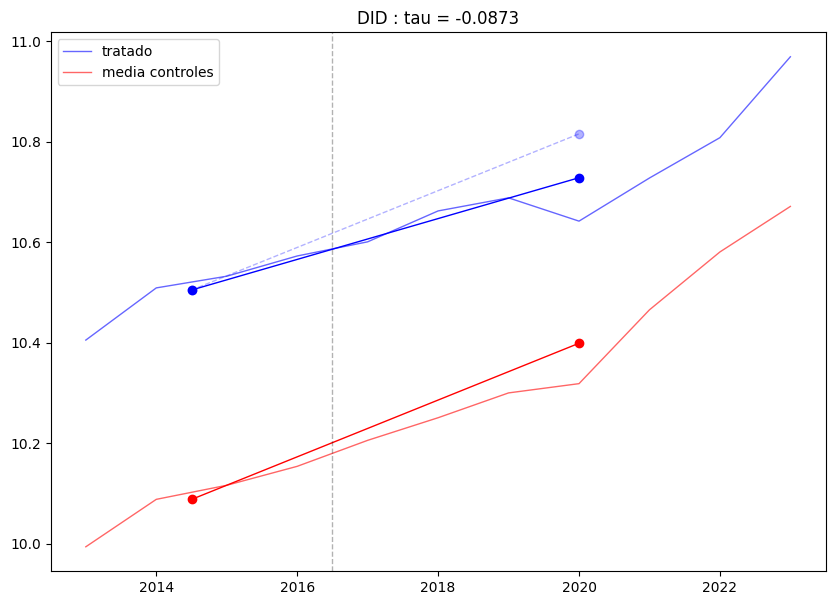

In [56]:
sdid_a.plot(model="did");  plt.show()

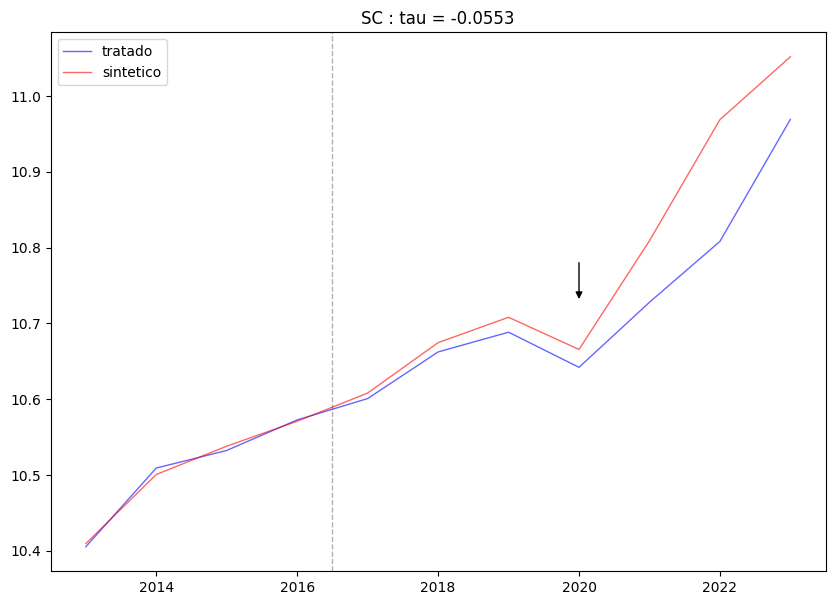

In [57]:
sdid_a.plot(model="sc");   plt.show()

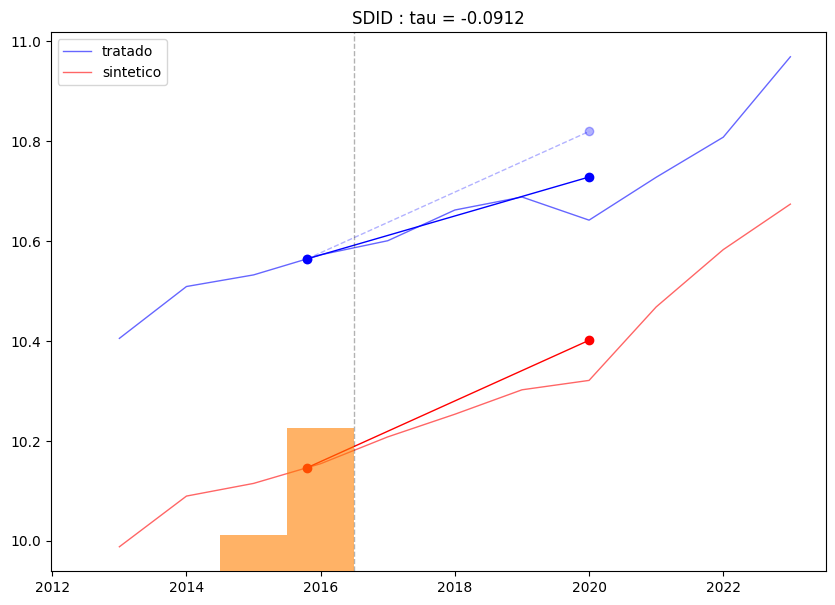

In [58]:
sdid_a.plot(model="sdid"); plt.show()

In [59]:
# Pesos do controle sintetico (SC)
omega_a = sdid_a.est_omega_ADH(sdid_a.Y_pre_c, sdid_a.Y_pre_t)
pesos_a = (
    pd.DataFrame({"Municipio": data_a.columns[data_a.columns != NOME_TRATADO],
                  "Peso SC": omega_a.flatten()})
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_a


,Municipio,Peso SC
0,Vinhedo,0.060800
1,Nova Lima,0.048442
2,São Caetano do Sul,0.044505
3,Goiana,0.038349
4,Itajaí,0.035657
5,Ipojuca,0.026003
6,Araucária,0.025898
7,Arujá,0.020323
8,Niterói,0.019654
9,Itabirito,0.016131


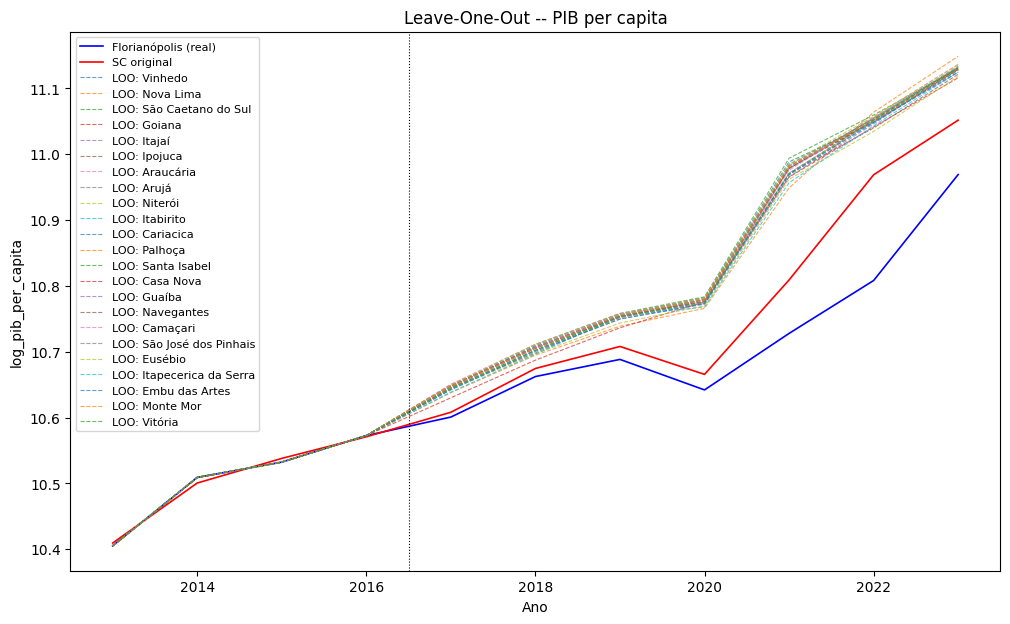

In [60]:
# Leave-One-Out: remove cada municipio com peso > 0.01 e reestima o SC
unidades_a = pesos_a["Municipio"].tolist()
sc_orig_a  = sdid_a.sc_potentical_outcome().values.flatten()
real_a     = data_a[NOME_TRATADO].values
anos_a     = np.array(data_a.index, dtype=float)

loo_a = {}
for u in unidades_a:
    _m = SynthDID(data_a.drop(columns=[u]), PRE_TERM, POST_TERM_PIB, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_a[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_a, real_a,    color="blue", lw=1.2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_a, sc_orig_a, color="red",  lw=1.2, label="SC original")
for u, traj in loo_a.items():
    plt.plot(anos_a, traj, ls="--", lw=0.8, alpha=0.7, label=f"LOO: {u}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP)
plt.title("Leave-One-Out -- PIB per capita")
plt.legend(fontsize=8); plt.show()


LOO mais proximo: Niterói (RMSE=0.1468)

  Niterói                             RMSE = 0.146758  <--
  Goiana                              RMSE = 0.148350
  Itabirito                           RMSE = 0.148575
  Ipojuca                             RMSE = 0.151395
  Itajaí                              RMSE = 0.152631
  Embu das Artes                      RMSE = 0.153720
  Itapecerica da Serra                RMSE = 0.153937
  Nova Lima                           RMSE = 0.154380
  Palhoça                             RMSE = 0.155165
  Araucária                           RMSE = 0.155543
  Vitória                             RMSE = 0.156119
  Cariacica                           RMSE = 0.156871
  Casa Nova                           RMSE = 0.157496
  Navegantes                          RMSE = 0.158539
  Arujá                               RMSE = 0.158548
  Monte Mor                           RMSE = 0.158556
  São José dos Pinhais                RMSE = 0.159313
  Camaçari                          

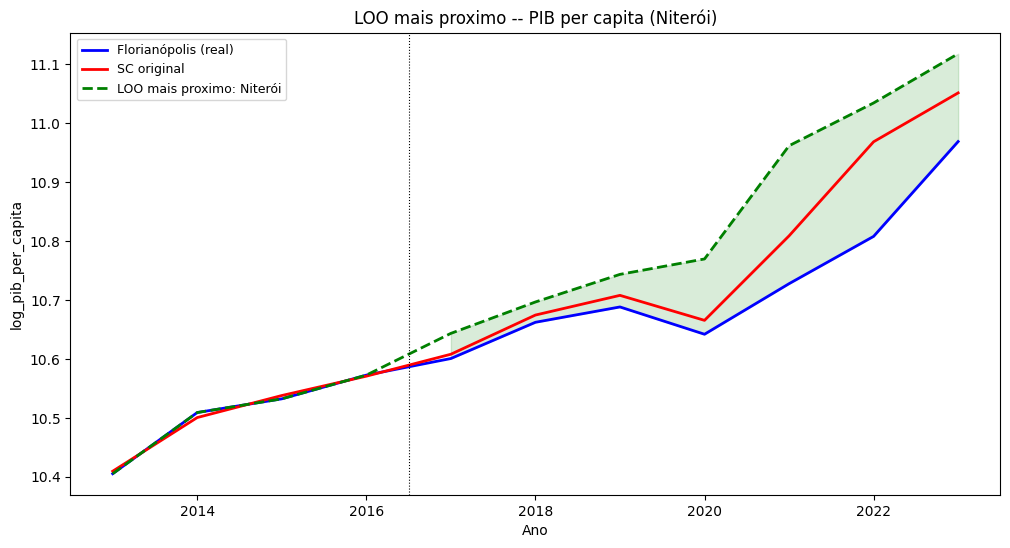

In [61]:
# LOO mais proximo da trajetoria real no pos-tratamento (menor RMSE)
_mask = anos_a >= ANO_TRATAMENTO
rmse_a = {u: np.sqrt(np.mean((t[_mask] - real_a[_mask])**2)) for u, t in loo_a.items()}
prox_a = min(rmse_a, key=rmse_a.get)
print(f"LOO mais proximo: {prox_a} (RMSE={rmse_a[prox_a]:.4f})\n")
for u, r in sorted(rmse_a.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_a else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_a, real_a,        color="blue",  lw=2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_a, sc_orig_a,     color="red",   lw=2, label="SC original")
plt.plot(anos_a, loo_a[prox_a], color="green", lw=2, ls="--", label=f"LOO mais proximo: {prox_a}")
plt.fill_between(anos_a[_mask], real_a[_mask], loo_a[prox_a][_mask], color="green", alpha=0.15)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP)
plt.title(f"LOO mais proximo -- PIB per capita ({prox_a})")
plt.legend(fontsize=9); plt.show()


### Event study — PIB per capita


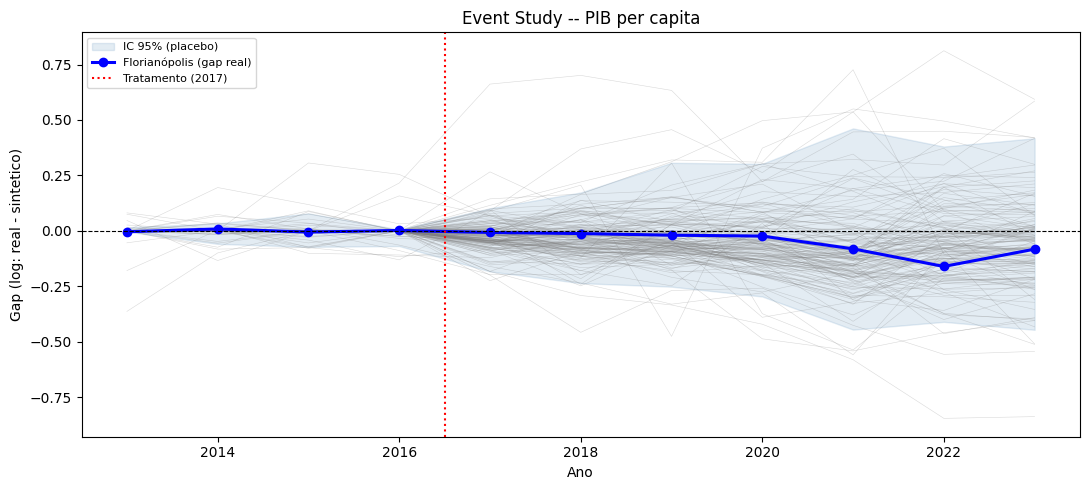

,Gap (log),"IC 2,5%","IC 97,5%",Efeito (%)
Ano,,,,
2013,-0.0042,-0.0036,0.0159,-0.4237
2014,0.0085,-0.0587,0.0332,0.8552
2015,-0.0056,-0.0721,0.0785,-0.5614
2016,0.0018,-0.0685,0.0065,0.1786
2017,-0.0073,-0.1830,0.1017,-0.7256
2018,-0.0123,-0.2359,0.1731,-1.2192
2019,-0.0197,-0.2517,0.3069,-1.9475
2020,-0.0236,-0.2961,0.3023,-2.3313
2021,-0.0812,-0.4455,0.4619,-7.7966


In [62]:
# Event study: gap (real - sintetico SC) ano a ano com bandas via placebo
_anos_es = np.array(data_a.index, dtype=float)
_real    = sdid_a.target_y().reindex(data_a.index).values
_sint    = sdid_a.sc_potentical_outcome().reindex(data_a.index).values
_gap_real = _real - _sint

# Gaps dos placebos: trata cada controle como se fosse o tratado
_controles_es = [c for c in data_a.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _c in _controles_es:
    try:
        _m = SynthDID(data_a, PRE_TERM, POST_TERM_PIB, [_c])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_a.index).values
              - _m.sc_potentical_outcome().reindex(data_a.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

# Banda de confianca 95% a partir da distribuicao dos placebos por ano
_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo, _hi, color="steelblue", alpha=0.15,
                label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g, color="gray", lw=0.4, alpha=0.3)
ax.plot(_anos_es, _gap_real, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (log: real - sintetico)")
ax.set_title("Event Study -- PIB per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Tabela do gap ano a ano com IC
display(
    pd.DataFrame({
        "Ano"      : _anos_es.astype(int),
        "Gap (log)": _gap_real,
        "IC 2,5%"  : _lo,
        "IC 97,5%" : _hi,
        "Efeito (%)": (np.exp(_gap_real) - 1) * 100,
    }).set_index("Ano").round(4)
)


---
## Seção B — PIB de serviços per capita


In [63]:
VAR_DEP_B = "log_pib_servicos_per_capita"

_df = (
    df_combinado[
        df_combinado["id_municipio"].isin(codigos_pool) &
        df_combinado["ano"].between(PRE_TERM[0], POST_TERM_SERV[1])
    ][["municipio", "ano", VAR_DEP_B]]
    .dropna(subset=[VAR_DEP_B])
)
_anos = set(range(PRE_TERM[0], POST_TERM_SERV[1] + 1))
_ok   = _df.groupby("municipio")["ano"].apply(lambda s: _anos.issubset(set(s)))
_ok   = _ok[_ok].index.tolist()

data_b = (
    _df[_df["municipio"].isin(_ok)]
    .pivot_table(index="ano", columns="municipio", values=VAR_DEP_B)
)
data_b.index = np.array(data_b.index, dtype=np.float64)
data_b.columns.name = None
print(f"Painel B: {data_b.shape[0]} anos x {data_b.shape[1]} municipios "
      f"({data_b.shape[1]-1} controles)")
data_b.head()


Painel B: 9 anos x 157 municipios (156 controles)


,Abreu e Lima,Aparecida de Goiânia,Apucarana,Aquiraz,Aracaju,Araguari,Arapongas,Araucária,Arujá,Balneário Camboriú,...,Valinhos,Valparaíso de Goiás,Viamão,Viana,Vila Velha,Vinhedo,Vitória,Vitória de Santo Antão,Várzea Grande,Águas Lindas de Goiás
2013.0,8.600442,9.300041,9.192415,9.017973,9.546168,9.249392,9.591685,10.763228,9.893578,9.978486,...,10.065214,8.794134,8.573559,9.191805,9.444589,10.769187,10.610736,9.191392,9.353683,8.067997
2014.0,8.815729,9.481548,9.310275,9.268508,9.596937,9.355263,9.619554,10.699856,10.292010,10.100372,...,10.145993,8.972441,8.665158,9.282087,9.607138,10.933406,10.688157,9.428951,9.474897,8.240224
2015.0,8.694309,9.459990,9.389286,9.350917,9.677176,9.425097,9.640272,10.672530,10.629008,10.158814,...,10.130692,9.034599,8.754055,9.453675,9.597469,10.961965,10.749864,9.387193,9.521476,8.319021
2016.0,8.703740,9.462063,9.399183,9.489425,9.705462,9.465018,9.641556,10.624127,10.610067,10.139771,...,10.134262,9.077795,8.858930,9.524029,9.612777,11.017514,10.652258,9.434263,9.680094,8.342127
2017.0,9.212406,9.537499,9.442172,9.547839,9.702975,9.542566,9.735886,10.706595,10.725150,10.175412,...,10.188794,9.145940,8.820285,9.684382,9.645251,11.057895,10.644094,9.504182,9.783490,8.430023


In [64]:
if USAR_COVARIAVEIS:
    _cov = (
        df_combinado[
            df_combinado["municipio"].isin(data_b.columns) &
            (df_combinado["ano"] <= ANO_TRATAMENTO - 1)
        ].groupby("municipio")[PREDICTORS].mean().T.reindex(columns=data_b.columns)
    )
    add_X_b = _cov.drop(columns=[NOME_TRATADO])
    add_y_b = _cov[NOME_TRATADO]
else:
    add_X_b, add_y_b = pd.DataFrame(), pd.DataFrame()


In [65]:
sdid_b = SynthDID(data_b, PRE_TERM, POST_TERM_SERV, [NOME_TRATADO])
sdid_b.fit(zeta_type="base", additional_X=add_X_b, additional_y=add_y_b)

var_b = sdid_b.estimate_variance(algo="placebo", replications=N_REPLICATIONS)
for modelo, v in zip(["sdid", "sc", "did"], var_b):
    att = sdid_b.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<5} ATT={att:+.4f} ({(np.exp(att)-1)*100:+.1f}%) "
          f"SE={se:.4f}  p={p:.3f}")


  0%|          | 0/200 [00:00<?, ?it/s]c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
 80%|████████  | 161/200 [05:53<01:23,  2.14s/it]c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
 90%|█████████ | 180/200 [06:32<00:42,  2.12s/it]c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
100%|██████████| 200/200 [07:14<00:00,  2.17s/it]

SDID  ATT=-0.0333 (-3.3%) SE=0.0830  p=0.688
SC    ATT=+0.0153 (+1.5%) SE=0.0922  p=0.868
DID   ATT=-0.0422 (-4.1%) SE=0.1231  p=0.732


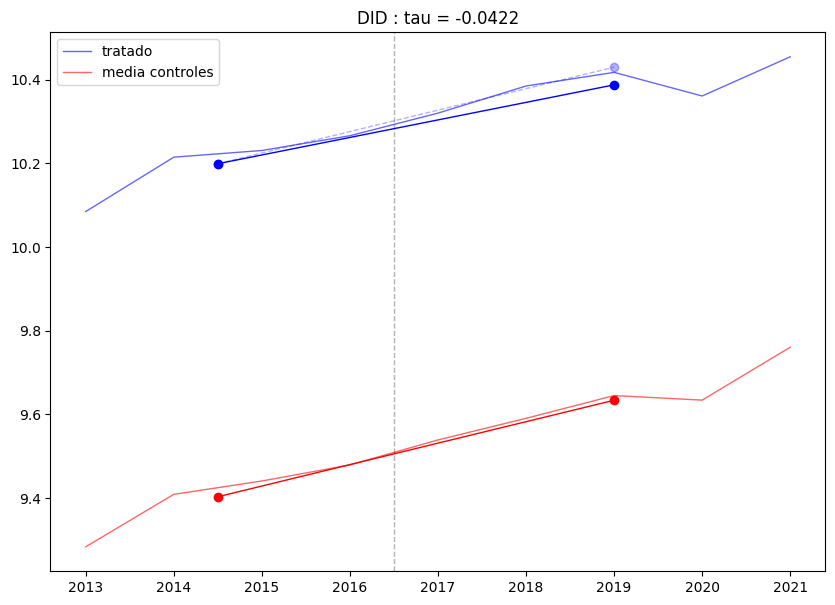

In [66]:
sdid_b.plot(model="did");  plt.show()

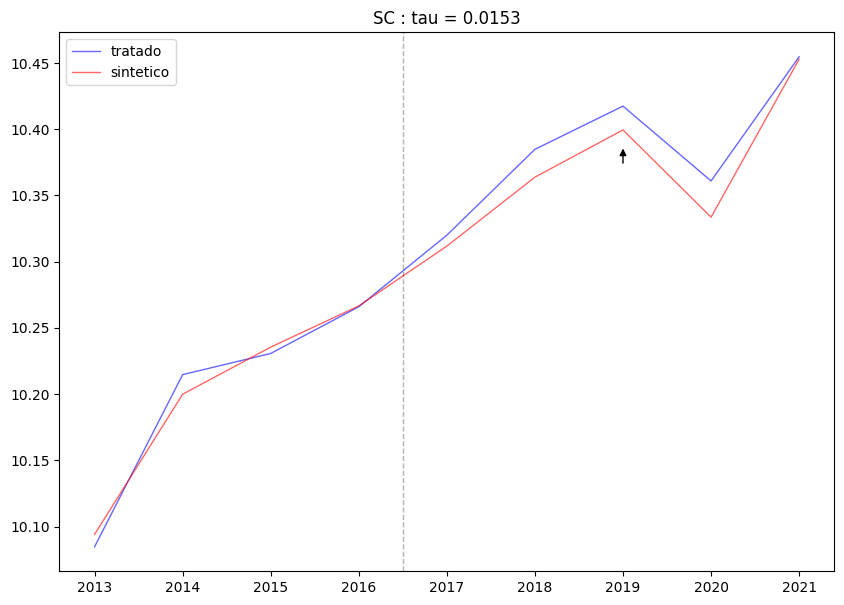

In [67]:
sdid_b.plot(model="sc");   plt.show()

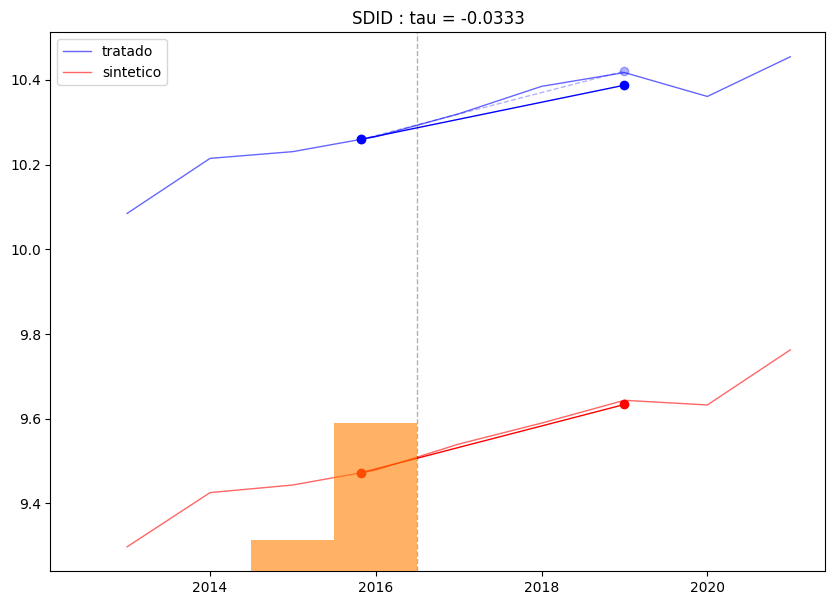

In [68]:
sdid_b.plot(model="sdid"); plt.show()

In [69]:
omega_b = sdid_b.est_omega_ADH(sdid_b.Y_pre_c, sdid_b.Y_pre_t)
pesos_b = (
    pd.DataFrame({"Municipio": data_b.columns[data_b.columns != NOME_TRATADO],
                  "Peso SC": omega_b.flatten()})
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_b


,Municipio,Peso SC
0,Itajaí,0.198268
1,Vinhedo,0.138250
2,São Caetano do Sul,0.126014
3,Eusébio,0.028492
4,Arujá,0.019729
5,Goiana,0.018152
6,Araucária,0.013339
7,Imperatriz,0.012689
8,Guaíba,0.011886
9,Carpina,0.010088


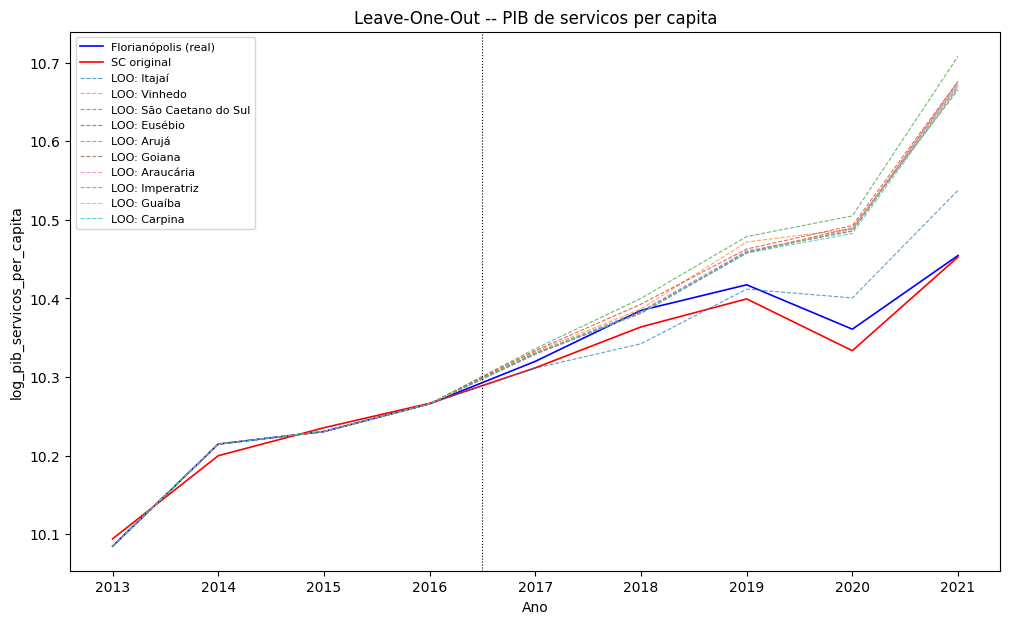

In [70]:
unidades_b = pesos_b["Municipio"].tolist()
sc_orig_b  = sdid_b.sc_potentical_outcome().values.flatten()
real_b     = data_b[NOME_TRATADO].values
anos_b     = np.array(data_b.index, dtype=float)

loo_b = {}
for u in unidades_b:
    _m = SynthDID(data_b.drop(columns=[u]), PRE_TERM, POST_TERM_SERV, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_b[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_b, real_b,    color="blue", lw=1.2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_b, sc_orig_b, color="red",  lw=1.2, label="SC original")
for u, traj in loo_b.items():
    plt.plot(anos_b, traj, ls="--", lw=0.8, alpha=0.7, label=f"LOO: {u}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP_B)
plt.title("Leave-One-Out -- PIB de servicos per capita")
plt.legend(fontsize=8); plt.show()


LOO mais proximo: Itajaí (RMSE=0.0455)

  Itajaí                              RMSE = 0.045545  <--
  Carpina                             RMSE = 0.111454
  Goiana                              RMSE = 0.112054
  Imperatriz                          RMSE = 0.113068
  Guaíba                              RMSE = 0.113714
  Araucária                           RMSE = 0.114494
  Arujá                               RMSE = 0.115476
  Vinhedo                             RMSE = 0.115955
  Eusébio                             RMSE = 0.117331
  São Caetano do Sul                  RMSE = 0.133683


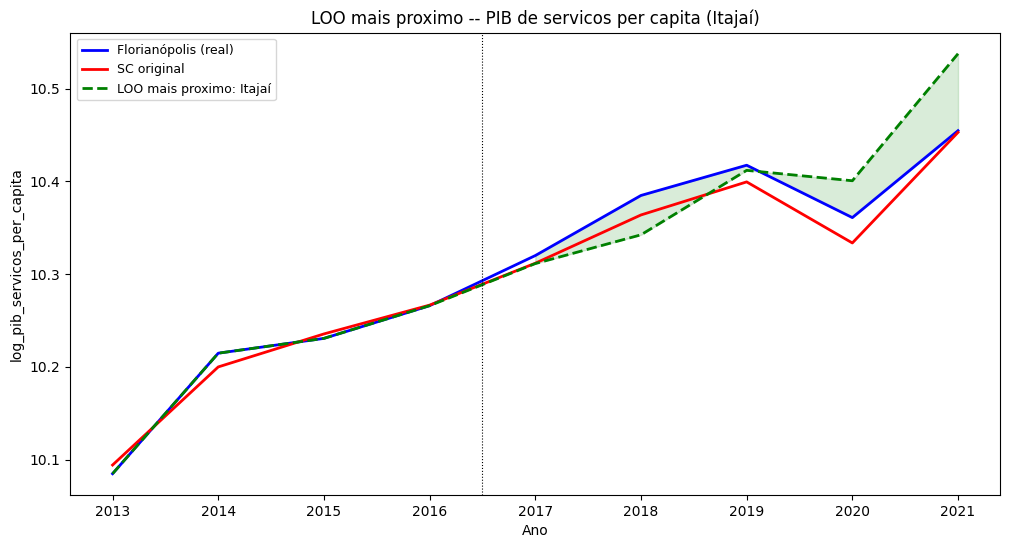

In [71]:
_mask = anos_b >= ANO_TRATAMENTO
rmse_b = {u: np.sqrt(np.mean((t[_mask] - real_b[_mask])**2)) for u, t in loo_b.items()}
prox_b = min(rmse_b, key=rmse_b.get)
print(f"LOO mais proximo: {prox_b} (RMSE={rmse_b[prox_b]:.4f})\n")
for u, r in sorted(rmse_b.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_b else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_b, real_b,        color="blue",  lw=2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_b, sc_orig_b,     color="red",   lw=2, label="SC original")
plt.plot(anos_b, loo_b[prox_b], color="green", lw=2, ls="--", label=f"LOO mais proximo: {prox_b}")
plt.fill_between(anos_b[_mask], real_b[_mask], loo_b[prox_b][_mask], color="green", alpha=0.15)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP_B)
plt.title(f"LOO mais proximo -- PIB de servicos per capita ({prox_b})")
plt.legend(fontsize=9); plt.show()


### Event study — PIB de serviços per capita


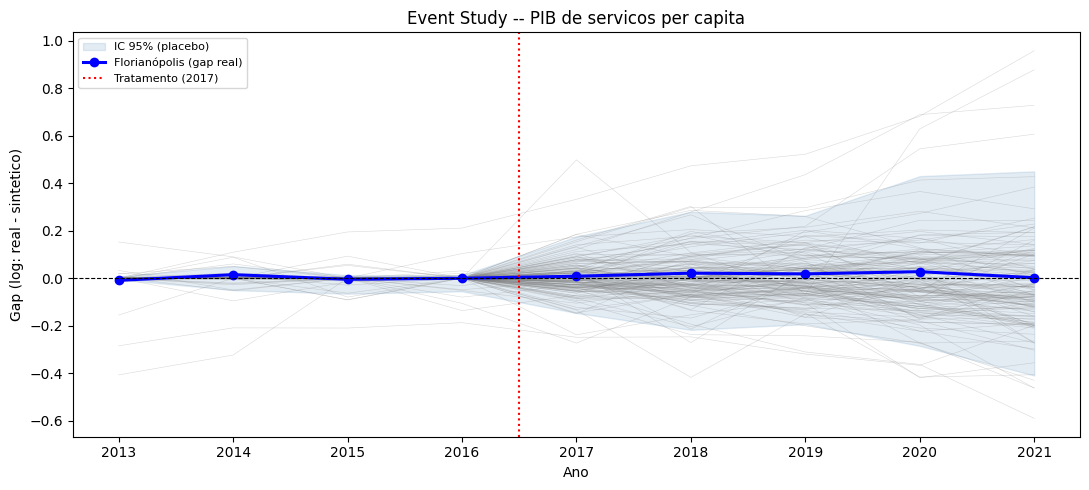

,Gap (log),"IC 2,5%","IC 97,5%",Efeito (%)
Ano,,,,
2013,-0.0094,-0.0052,0.0076,-0.9324
2014,0.0148,-0.0502,0.0508,1.4913
2015,-0.0048,-0.0654,0.0128,-0.4794
2016,-0.0006,-0.0554,0.0122,-0.0627
2017,0.0083,-0.1467,0.1751,0.8291
2018,0.0210,-0.2178,0.2797,2.1243
2019,0.0180,-0.1939,0.2629,1.8145
2020,0.0274,-0.2853,0.4299,2.7730
2021,0.0018,-0.4099,0.4501,0.1814


In [72]:
# Event study: gap (real - sintetico SC) ano a ano com bandas via placebo
_anos_es = np.array(data_b.index, dtype=float)
_real    = sdid_b.target_y().reindex(data_b.index).values
_sint    = sdid_b.sc_potentical_outcome().reindex(data_b.index).values
_gap_real = _real - _sint

# Gaps dos placebos: trata cada controle como se fosse o tratado
_controles_es = [c for c in data_b.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _c in _controles_es:
    try:
        _m = SynthDID(data_b, PRE_TERM, POST_TERM_SERV, [_c])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_b.index).values
              - _m.sc_potentical_outcome().reindex(data_b.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

# Banda de confianca 95% a partir da distribuicao dos placebos por ano
_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo, _hi, color="steelblue", alpha=0.15,
                label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g, color="gray", lw=0.4, alpha=0.3)
ax.plot(_anos_es, _gap_real, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (log: real - sintetico)")
ax.set_title("Event Study -- PIB de servicos per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Tabela do gap ano a ano com IC
display(
    pd.DataFrame({
        "Ano"      : _anos_es.astype(int),
        "Gap (log)": _gap_real,
        "IC 2,5%"  : _lo,
        "IC 97,5%" : _hi,
        "Efeito (%)": (np.exp(_gap_real) - 1) * 100,
    }).set_index("Ano").round(4)
)
